In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

In [2]:
from astropy import units as un, constants as cons
import numpy as np
import matplotlib.pyplot as plt
import glob,h5py
from scipy.interpolate import RegularGridInterpolator

In [3]:
plt.rcParams['font.size']=18
plt.rcParams['axes.linewidth']=2
plt.rcParams['xtick.major.size']=10
plt.rcParams['xtick.minor.size']=5
plt.rcParams['xtick.major.width']=2
plt.rcParams['xtick.minor.width']=1
plt.rcParams['xtick.direction']='in'
plt.rcParams['ytick.major.size']=10
plt.rcParams['ytick.minor.size']=5
plt.rcParams['ytick.major.width']=2
plt.rcParams['ytick.minor.width']=1
plt.rcParams['ytick.direction']='in'

In [4]:
Msun = 1.988409870698051e+33
G = 6.674299999999999e-08
mp = 1.67262192369e-24
kpc = 3.0856775814913673e+21
gamma = 5./3.
yr_to_sec = 3.154e+7
Myr = yr_to_sec * 1.e6
kmps = 1.e5
kb = 1.38e-16
Z2Zsun = 1.

cloudy_H_mass_fraction = 1. / (1. + 0.1 * 3.971)
X = cloudy_H_mass_fraction
Z = 0.02  # metal fraction by mass
Y = 1. - X - Z
mean_metals_A = 16.  # mean atomic weight of metals
sigma_T = 6.6524e-25  
electron_mass_cgs = 9.1093897e-28  # electron mass (g)
mu = 0.6
m_H = 1.672623e-24  # g
T_cmb = 2.725  # * (1 + z); // K
c_light_cgs_ = 2.99792458e10  # cgs
radiation_constant_cgs_ = 7.5646e-15  # cgs
boltzmann_constant_cgs_ = 1.380658e-16  # cgs

In [132]:
10.**lognHbins[4]

np.float64(1e-08)

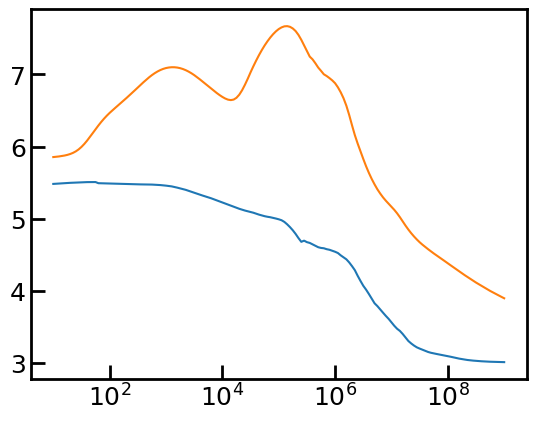

In [184]:
plt.plot(Tbins, np.log10(net_metprim_heating[idx1]/ net_metprim_heating[idx2]))
plt.plot(Tbins, np.log10(net_metprim_cooling[idx1]/ net_metprim_cooling[idx2]))
plt.xscale('log')
# plt.ylim(5., 6.)

(1e-45, 1e-21)

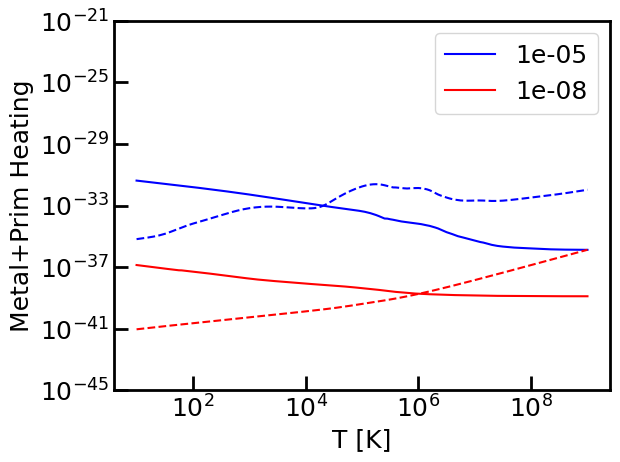

In [237]:
vmin, vmax = (1.e-45, 1.e-21)
filename = "/Users/aditivijayan/quokka/INCITE/dwGal_setup/HaloProfile/cooling_flow_stern-19/GalaxyIC_for_Quokka/CloudyData_UVB=HM2012.h5"
# filename = "/Users/aditivijayan/quokka/INCITE/dwGal_setup/HaloProfile/cooling_flow_stern-19/GalaxyIC_for_Quokka/CloudyData_UVB=HM2012_shielded.h5"
with h5py.File(filename, "r") as f:
    metal_cooling = f["CoolingRates/Metals/Cooling"][:,0,:]
    metal_heating = f["CoolingRates/Metals/Heating"][:,0,:]
    primordial_cooling = f["CoolingRates/Primordial/Cooling"][:,0,:]
    primordial_heating = f["CoolingRates/Primordial/Heating"][:,0,:]
    lognHbins = f['CoolingRates/Metals/Cooling'].attrs['Parameter1']
    Tbins = f['CoolingRates/Metals/Cooling'].attrs['Temperature']

nHgrid,  Tgrid = np.meshgrid(10.** lognHbins, Tbins, indexing='ij')
net_metprim_heating =  nHgrid ** 2 * (metal_heating + primordial_heating)
net_metprim_cooling =  nHgrid ** 2 * (metal_cooling + primordial_cooling)

idx1 = 10 #1.e-5
idx2 = 14 #1.e-3
idx2 = 16 #0.1
idx2 = 4
plt.plot(Tbins, net_metprim_heating[idx1], color='blue', label='%.e'%(10.**lognHbins[idx1]))
plt.plot(Tbins, net_metprim_heating[idx2], color='red', label='%.e'%(10.**lognHbins[idx2]))

plt.plot(Tbins, net_metprim_cooling[idx1], color='blue', ls='--')
plt.plot(Tbins, net_metprim_cooling[idx2], color='red', ls='--')
plt.xscale('log')
plt.xlabel('T [K]')
plt.ylabel('Metal+Prim Heating')
plt.legend(loc='upper right')
plt.yscale('log')
plt.ylim(vmin, vmax)


Text(0.5, 1.0, '3162.3 K')

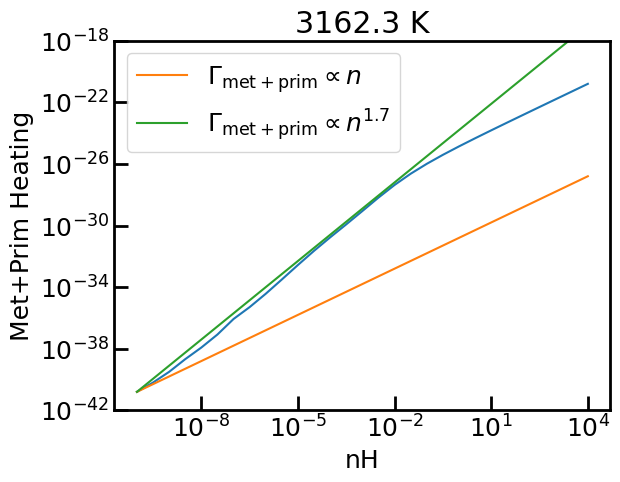

In [249]:
tidx = 21
tidx = 50
# tidx = 70
plt.plot(nHgrid[:,0], net_metprim_heating[:,tidx])
y = net_metprim_heating[0,tidx] * (nHgrid[:,0]/nHgrid[0,0])
plt.plot(nHgrid[:,0],y, label=r'$\Gamma_{\rm met+prim}\propto n$')

y = net_metprim_heating[0,tidx] * (nHgrid[:,0]/nHgrid[0,0])**1.7
plt.plot(nHgrid[:,0],y, label=r'$\Gamma_{\rm met+prim}\propto n^{1.7}$')

plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.ylabel(r'Met+Prim Heating')
plt.xlabel('nH')
plt.ylim(1.e-42, 1.e-18)
plt.title('%.1f'%Tbins[tidx] + ' K')
# plt.ylim(5., 6.)

In [157]:
rhoHgrid = nHgrid* m_H
rho = rhoHgrid / cloudy_H_mass_fraction


#Photoelectric Cooling Rate
n_e = (rho / m_H) * \
                 (1.0 - mu * (X + Y / 4. + Z / mean_metals_A)) / \
                 (mu - ( electron_mass_cgs / m_H))

n_e = np.maximum(n_e, 1.e-4 * nHgrid)
Tsqrt = np.sqrt(Tgrid)
phi = 0.5  # phi_PAH from Wolfire et al. (2003)
G_0 = 1.7  # ISRF from Wolfire et al. (2003)
epsilon = \
4.9e-2 / (1. + 4.0e-3 * (G_0 * Tsqrt / (n_e * phi))**0.73) + \
3.7e-2 * (Tgrid / 1.0e4)**(0.7) / \
    (1. + 2.0e-4 * (G_0 * Tsqrt / (n_e * phi)))
Gamma_pe = 1.3e-24 * nHgrid * epsilon * G_0

cooling_rate_PE = 1. * (Z2Zsun * Gamma_pe)  

Text(0.5, 1.0, '3162.3 K')

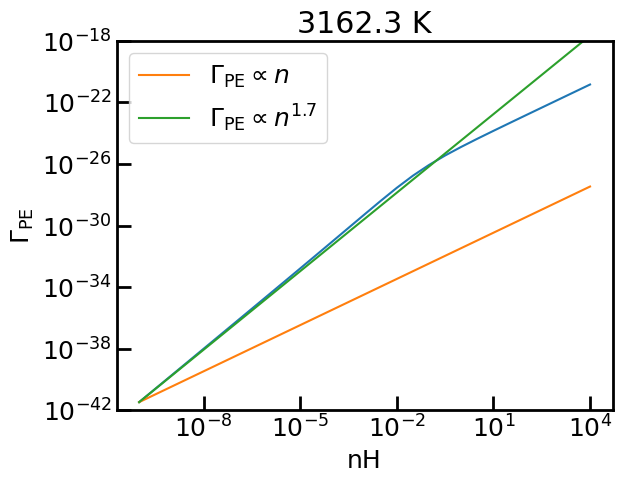

In [233]:
# plt.plot(Tbins, np.log10(cooling_rate_PE[idx1]/ cooling_rate_PE[idx2]))
tidx = 21
tidx = 50
# tidx = 70
plt.plot(nHgrid[:,0], cooling_rate_PE[:,tidx])
y = cooling_rate_PE[0,tidx] * (nHgrid[:,0]/nHgrid[0,0])
plt.plot(nHgrid[:,0],y, label=r'$\Gamma_{\rm PE}\propto n$')

y = cooling_rate_PE[0,tidx] * (nHgrid[:,0]/nHgrid[0,0])**1.7
plt.plot(nHgrid[:,0],y, label=r'$\Gamma_{\rm PE}\propto n^{1.7}$')

plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.ylabel(r'$\Gamma_{\rm PE}$')
plt.xlabel('nH')
plt.ylim(1.e-42, 1.e-18)
plt.title('%.1f'%Tbins[tidx] + ' K')
# plt.ylim(5., 6.)

Max ratio = 5.18615344965556


(1e-45, 1e-21)

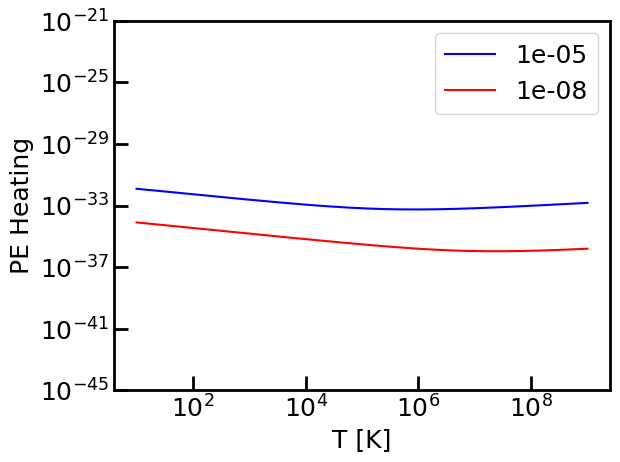

In [187]:

plt.plot(Tbins, cooling_rate_PE[idx1],color='blue', label='%.e'%(10.**lognHbins[idx1]))
plt.plot(Tbins, 1.e3*cooling_rate_PE[idx2], color='red', label='%.e'%(10.**lognHbins[idx2]))

plt.xscale('log')
plt.xlabel('T [K]')
plt.ylabel('PE Heating')
plt.legend()
plt.yscale('log')
plt.ylim(1.e-37, 1.e-21)
ratio = np.log10(cooling_rate_PE[idx1]/cooling_rate_PE[idx2])
print('Max ratio =', np.amin(ratio))
plt.ylim(vmin, vmax)
# plt.ylim(1.e-34, 1.e-29)

(1e-45, 1e-21)

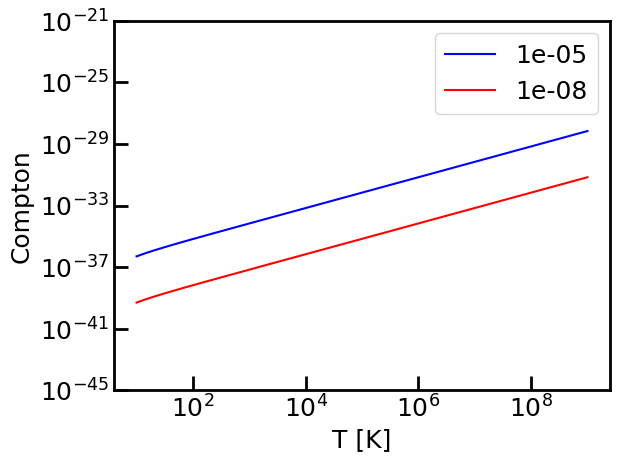

In [163]:
E_cmb = radiation_constant_cgs_ * (T_cmb * T_cmb * T_cmb * T_cmb)
Gamma_C = (8. * sigma_T * E_cmb) / (3. * cons.m_e.value * c_light_cgs_)
C_n     = Gamma_C * boltzmann_constant_cgs_ / (5. / 3. - 1.0)
compton_CMB =  (C_n * (Tgrid - T_cmb) * n_e)  

plt.plot(Tbins, compton_CMB[idx1], color='blue', label='%.e'%(10.**lognHbins[idx1]))
plt.plot(Tbins, compton_CMB[idx2], color='red', label='%.e'%(10.**lognHbins[idx2]))

plt.xscale('log')
plt.xlabel('T [K]')
plt.ylabel('Compton')
plt.legend()
plt.yscale('log')
plt.ylim(vmin, vmax)